In [1]:
import torch
import torchvision
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import numpy as np
from torchvision.utils import make_grid
from tqdm import trange

In [2]:
torch.cuda.is_available()

True

In [ ]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((.5, .5, .5), (.5, .5, .5)),
    # v2.Lambda(lambda x: x + torch.rand_like(x) * 3e-2),
])
denormalize = v2.Normalize((-1., -1., -1.), (2., 2., 2.))
dataset = torchvision.datasets.CIFAR10(root='datasets', transform=transform, download=True, train=True)

Files already downloaded and verified


In [4]:
dataloader = DataLoader(dataset, batch_size=16, shuffle=False, num_workers=4)

In [5]:
imgs, labels = next(dataloader.__iter__())

In [6]:
def show_img(imgs, figsize=None):
    if not isinstance(imgs, list):
        imgs = [imgs]
    if figsize:
        fig, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize=figsize)
    else:
        fig, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

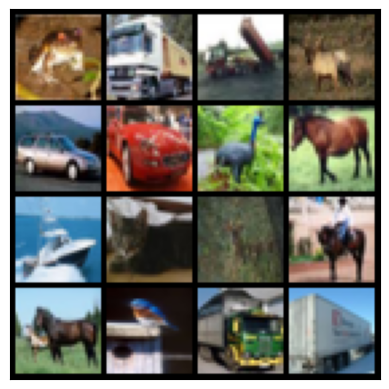

In [7]:
show_img(make_grid(denormalize(imgs), nrow=4))

# testing the metric on JEM

In [8]:
from models.JEM import JEM_F

In [9]:
depth = 28
width = 10
model = JEM_F(depth, width).to('cuda')
ckpt_dict = torch.load('trained_checkpoints/Grathwohl_CIFAR10_JEM.pt', map_location='cuda')
model.load_state_dict(ckpt_dict['model_state_dict'])

| Wide-Resnet 28x10


/tmp/user/5678/ipykernel_187435/845771390.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt_dict = torch.load('trained_checkpoints/Grathwohl_CIFAR10_JEM.pt', map_loca

<All keys matched successfully>

In [24]:
with torch.inference_mode():
    logits = model.classify(imgs.to('cuda')).cpu()

In [31]:
with torch.inference_mode():
    logits2 = model.classify(imgs.to('cuda')).cpu()

In [53]:
torch.cuda.memory_allocated()

432321024

In [29]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [45]:
label_grid = labels[:, None] == torch.arange(10)

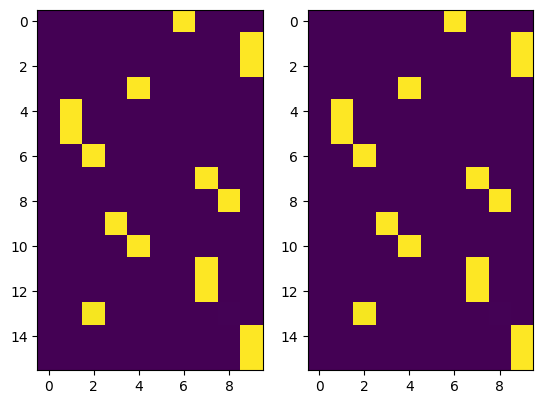

In [49]:
fig, axs = plt.subplots(1, 2)
axs[0].imshow(torch.softmax(logits, dim=-1))
axs[1].imshow(torch.softmax(logits, dim=-1))

In [15]:
def lerp(u: torch.Tensor, v: torch.Tensor, n=50) -> torch.Tensor:
    lbda = torch.linspace(0, 1, n)
    return torch.movedim(lbda * v[..., None] + (1-lbda) * u[..., None], -1, 0)

In [52]:
im1, im2 = imgs[:2]

In [ ]:
labels

tensor([6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9])

In [75]:
trucks = imgs[[1, 14]]
truck1, truck2 = trucks

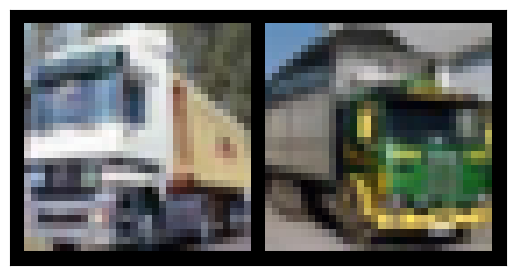

In [76]:
show_img(make_grid(denormalize(trucks)))

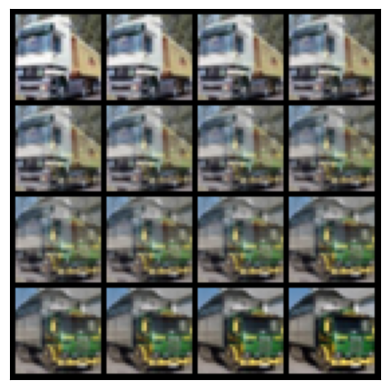

In [84]:
lin_line = lerp(truck1, truck2, n=16)
show_img(make_grid(denormalize(lin_line), nrow=4))

In [11]:
def posterior(x):
    logits = model.classify(x)
    return torch.softmax(logits, dim=-1)

In [12]:
def kinetic_curve_energy(curve: torch.Tensor):
    curve_pk = posterior(curve)
    ke = torch.sum(torch.square((curve_pk[1:] - curve_pk[:-1])))
    return ke

In [13]:
# trick for numerical stability of interpolant optimization
def subdivide_curve(curve, n_subdivisions=3):
    lmda = torch.linspace(0, 1, 2+n_subdivisions)[:-1][:, None]
    s = lmda * curve[1:, None] + (1-lmda) * curve[:-1, None]
    return torch.cat((torch.flatten(s, 0, 1), curve[-1][None]))

In [44]:
t = torch.tensor((1., 2.))

In [14]:
def optimize_geodesic(curve: torch.Tensor, n_iter=10000, lr=1e-3, n_subdiv=0):
    og_device = curve.device
    curve = curve.cuda()
    curve_interior = curve[1:-1].requires_grad_(True)
    optimizer = torch.optim.Adam([curve_interior], lr=lr)
    
    best_energy = np.inf
    best_curve = torch.empty_like(curve)
    pbar = trange(n_iter, desc='optimizing geodesic')
    for _ in pbar:
        optimizer.zero_grad()
        full_curve = torch.cat((curve[[0]], curve_interior, curve[[-1]]))
        subdiv_curve = subdivide_curve(full_curve, n_subdiv) if n_subdiv else full_curve
        curve_e: torch.Tensor = kinetic_curve_energy(subdiv_curve)
        if curve_e.item() < best_energy:
            best_curve = full_curve.detach()
        curve_e.backward()
        optimizer.step()
        pbar.set_postfix(loss=curve_e.item())
    
    return best_curve.to(og_device)

In [105]:
lin_line = lerp(truck1, truck2, n=256)

In [ ]:
geodesic = optimize_geodesic(lin_line.cuda(), n_iter=256).detach().cpu()

optimizing geodesic: 100%|██████████| 256/256 [02:47<00:00,  1.53it/s, loss=3.21e-8]


In [111]:
geodesic = geodesic.detach().cpu()

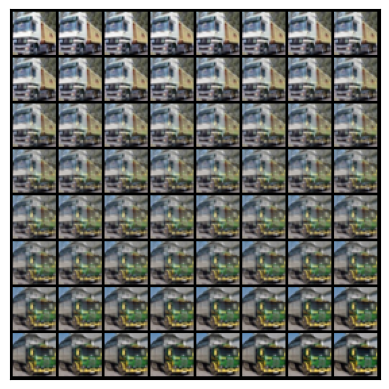

In [114]:
show_img(make_grid(denormalize(geodesic[::4]), nrow=8))

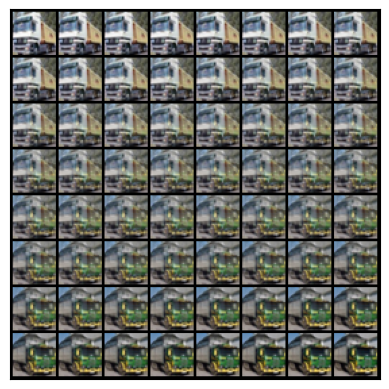

In [115]:
show_img(make_grid(denormalize(lin_line[::4]), nrow=8))

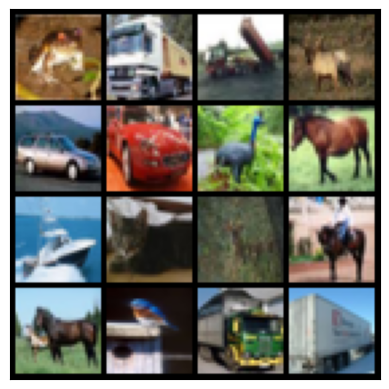

In [116]:
show_img(make_grid(denormalize(imgs), nrow=4))

optimizing geodesic: 100%|██████████| 500/500 [05:28<00:00,  1.52it/s, loss=0.0311]


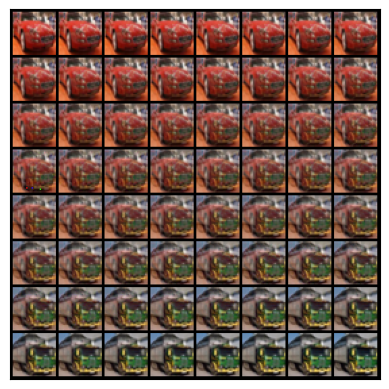

In [ ]:
red_car, green_truck = imgs[[5, 14]]
lin_line = lerp(red_car, green_truck, n=256)
geodesic = optimize_geodesic(lin_line, n_iter=500)
show_img(make_grid(denormalize(geodesic[::4]), nrow=8))

In [130]:
top_diff_idx = (geodesic - lin_line).norm(dim=(1, 2, 3), p=2).argmax()

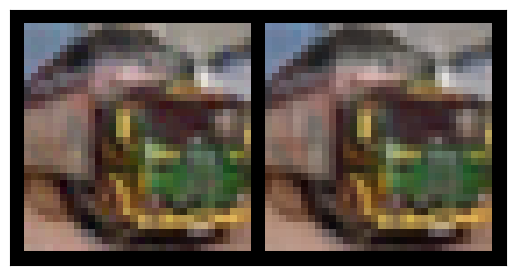

In [132]:
show_img(make_grid(denormalize(torch.stack((geodesic[top_diff_idx], lin_line[top_diff_idx])))))

In [141]:
silver_car, red_car = imgs[[4, 5]]
lin_line = lerp(silver_car, red_car, n=256)
# geodesic = optimize_geodesic(lin_line.cuda(), n_iter=1000).detach().cpu()
# show_img(make_grid(denormalize(geodesic[::4]), nrow=8))

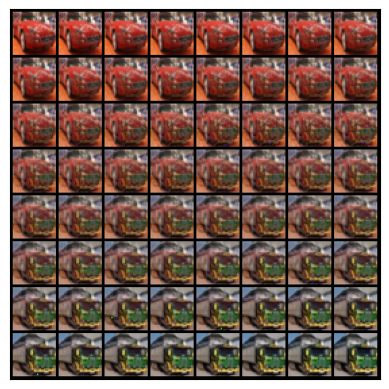

In [147]:
show_img(make_grid(denormalize(geodesic[::4]), nrow=8))

optimizing geodesic:   0%|          | 0/500 [00:00<?, ?it/s]

optimizing geodesic: 100%|██████████| 500/500 [05:32<00:00,  1.50it/s, loss=0.0244]


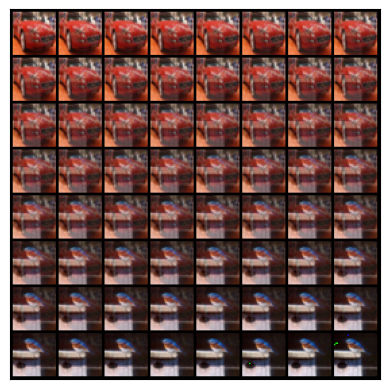

In [16]:
red_car, bird = imgs[[5, 13]]
lin_line = lerp(red_car, bird, n=256)
geodesic = optimize_geodesic(lin_line, n_iter=500)
show_img(make_grid(denormalize(geodesic[::4]), nrow=8))

In [24]:
with torch.inference_mode():
    geodesic_posterior = posterior(geodesic.cuda()).cpu()

In [25]:
p_car, p_bird = geodesic_posterior[:, [1, 2]].T

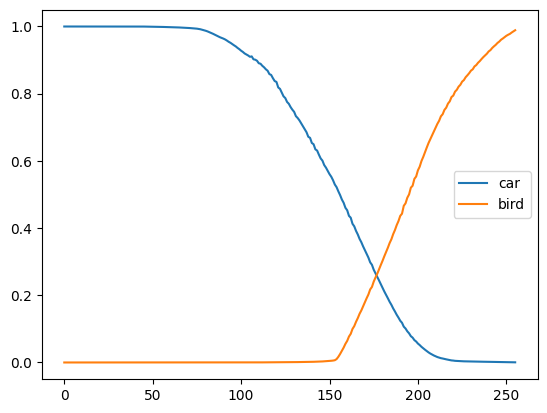

In [26]:
plt.plot(p_car, label='car')
plt.plot(p_bird, label='bird')
plt.legend()
plt.show()